In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
sns.set(style="whitegrid", font_scale=1.1)

In [3]:
ls

 Volume in drive E is New Volume
 Volume Serial Number is 4C38-9E90

 Directory of E:\Data_Science_Program

12/26/2025  09:19 PM    <DIR>          .
12/26/2025  09:19 PM    <DIR>          .ipynb_checkpoints
12/26/2025  09:18 PM    <DIR>          data
12/26/2025  09:17 PM    <DIR>          env
12/26/2025  09:19 PM               618 Titanic_data_EDA.ipynb
               1 File(s)            618 bytes
               4 Dir(s)  98,626,736,128 bytes free


### Load Dataset

In [3]:
train_df = pd.read_csv("data/train.csv")
test_df = pd.read_csv("data/test.csv")

### Loading 1st 10 rows of the dataframe

In [15]:
train_df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [11]:
train_df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [12]:
train_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [13]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [14]:
train_df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [35]:
%matplotlib inline

### Computed the proportion of passengers who survived and who did not survive.

In [5]:
surv_percentage = (train_df.Survived.value_counts().sort_index())/train_df.Survived.count()
surv_percentage

Survived
0    0.616162
1    0.383838
Name: count, dtype: float64

C:\Users\habiba\AppData\Local\Temp\ipykernel_31108\1586149180.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


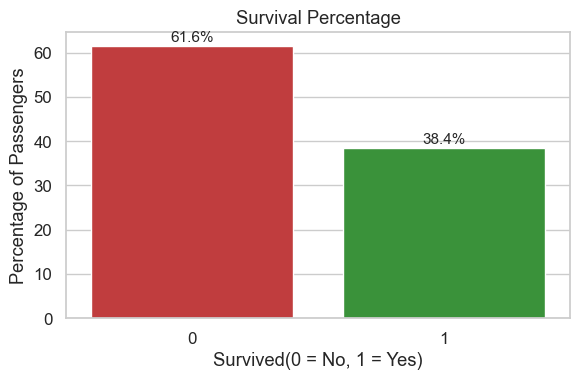

In [6]:
surv_prop = (train_df.Survived.value_counts().sort_index())/(train_df.Survived.count())*100
plt.figure(figsize=(6, 4))
ax = sns.barplot(
    x=surv_prop.index,
    y=surv_prop.values,
    palette=["#d62728", "#2ca02c"]
)
for i, v in enumerate(surv_prop.values):
    ax.text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=11)
ax.set_title("Survival Percentage")
ax.set_xlabel("Survived(0 = No, 1 = Yes)")
ax.set_ylabel("Percentage of Passengers")
plt.tight_layout()
plt.show()


In [104]:
train_df['Survived'].mean()

np.float64(0.3838383838383838)

## Checking whether female has survived more than male

In [123]:
percentage_ratio_by_sex = train_df["Sex"].value_counts()/train_df["Sex"].count() * 100
percentage_ratio_by_sex

Sex
male      64.758698
female    35.241302
Name: count, dtype: float64

 ## Visualized the distribution of passengers by gender using a bar plot

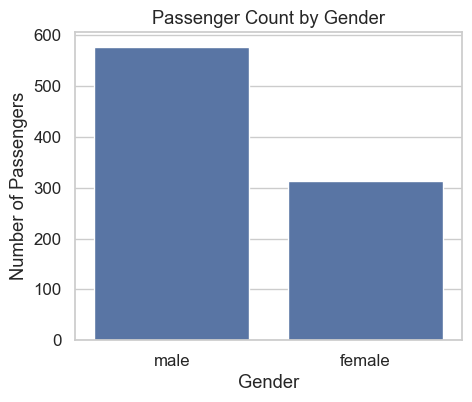

In [185]:
plt.figure(figsize=(5, 4))
sns.countplot(data=train_df, x = "Sex")
plt.title("Passenger Count by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.show()

In [117]:
surv_percentage_ratio_by_sex = train_df.groupby("Sex")["Survived"].mean() * 100
surv_percentage_ratio_by_sex

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64

C:\Users\habiba\AppData\Local\Temp\ipykernel_19224\553872158.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


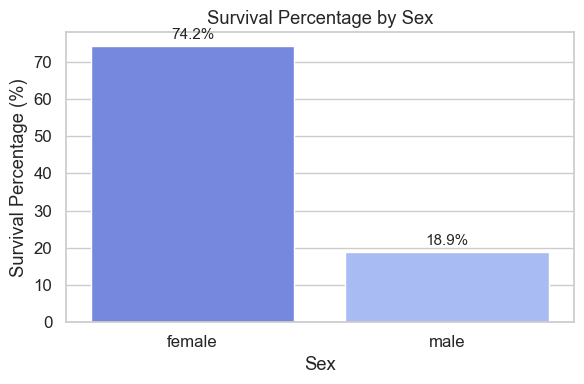

In [118]:
plt.figure(figsize=(6, 4))

ax = sns.barplot(
    x=surv_percentage_ratio_by_sex.index,
    y=surv_percentage_ratio_by_sex.values,  
    palette=["#647DEE", "#9BB5FF"]            
)
for i, v in enumerate(surv_percentage_ratio_by_sex.values):
    ax.text(i, v + 1, f"{v:.1f}%", ha="center", va="bottom", fontsize=11)
ax.set_title("Survival Percentage by Sex")
ax.set_xlabel("Sex")
ax.set_ylabel("Survival Percentage (%)")

plt.tight_layout()
plt.show()


### Female has survived more than male inspite of them being only 35.24%

## Histogram for age distribution

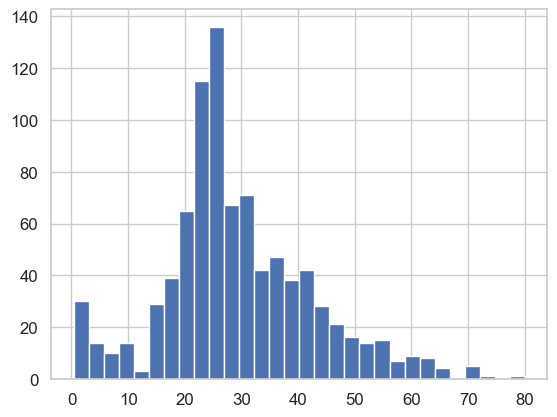

In [126]:
passenger_age_hist = train_df['Age'].hist(bins=30)

### Most of the passenger are in their 20s and 30s

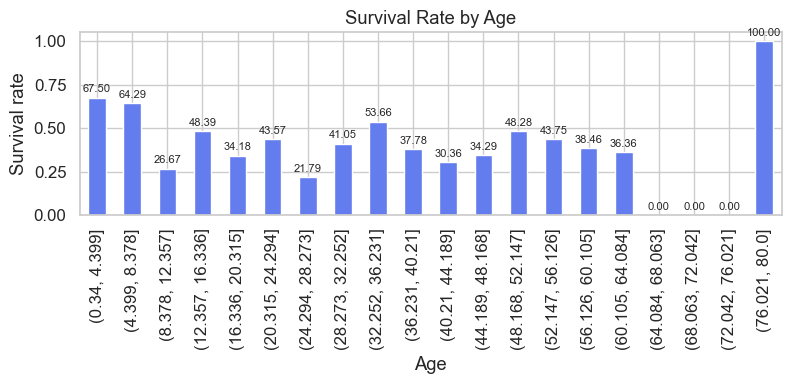

In [139]:
# 20 equal-width age bins
age_bins = pd.cut(train_df["Age"], 20)         
survival_by_age = (train_df["Survived"].groupby(age_bins,observed=False).mean())

plt.figure(figsize=(8, 4))
ax = survival_by_age.plot(kind="bar", color="#647DEE")
ax.set_xlabel("Age")
ax.set_ylabel("Survival rate")
ax.set_ylim(0, 1.05)
ax.set_title("Survival Rate by Age")

for i, v in enumerate(survival_by_age.values):
    ax.text(i, v + 0.03, f"{v*100:.2f}", ha="center", fontsize=8)

plt.tight_layout()
plt.show()

### Seems like children and older one's has higher survival rate

## Impact of Socio-Economic Class

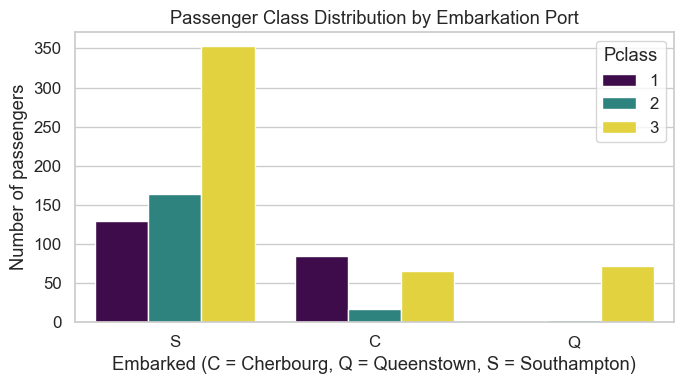

In [167]:
plt.figure(figsize=(7, 4))
sns.countplot(
    data=train_df,
    x="Embarked",
    hue="Pclass",
    hue_order=[1, 2, 3],
    palette="viridis"
)
plt.title("Passenger Class Distribution by Embarkation Port")
plt.xlabel("Embarked (C = Cherbourg, Q = Queenstown, S = Southampton)")
plt.ylabel("Number of passengers")
plt.legend(title="Pclass")
plt.tight_layout()
plt.show()

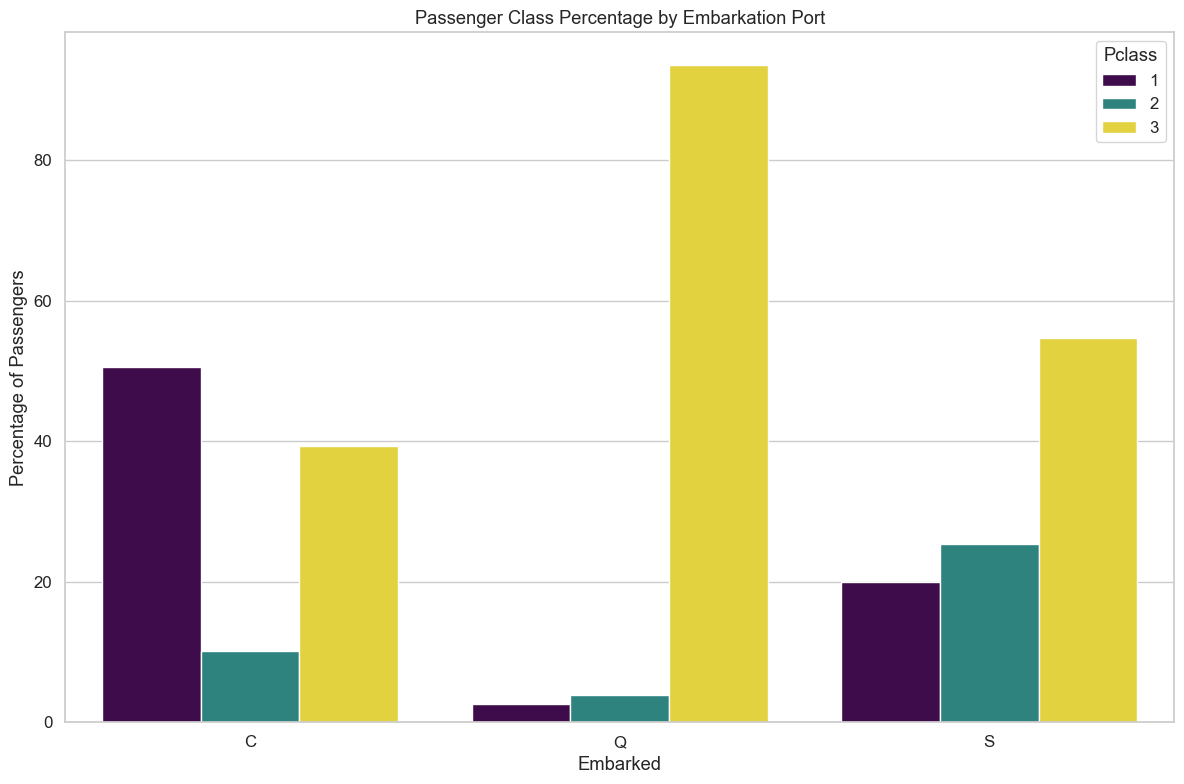

In [183]:
number_of_passenger_Pclass = (
    train_df
    .groupby("Embarked")["Pclass"]
    .value_counts(normalize=True)   
    .mul(100)                       
    .rename("percent")
    .reset_index()                  
)
plt.figure(figsize=(12, 8))
ax = sns.barplot(
    data=number_of_passenger_Pclass,
    x="Embarked",
    y="percent",
    hue="Pclass",
    hue_order=[1, 2, 3],
    palette="viridis"
)

ax.set_title("Passenger Class Percentage by Embarkation Port")
ax.set_ylabel("Percentage of Passengers")
plt.tight_layout()
plt.show()

### A large number of passengers embarking at Cherbourg (C) were 1st‑class, while those embarking at Southampton (S) and Queenstown (Q) were predominantly 3rd‑class.


<Axes: xlabel='Pclass'>

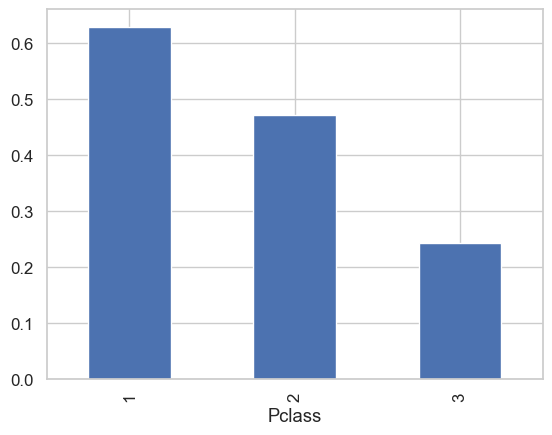

In [157]:
(train_df["Survived"].groupby(train_df.Pclass,observed=False).mean()).plot(kind='bar')

### 1st Class passengers have a higher survival rate

<Axes: xlabel='Fare'>

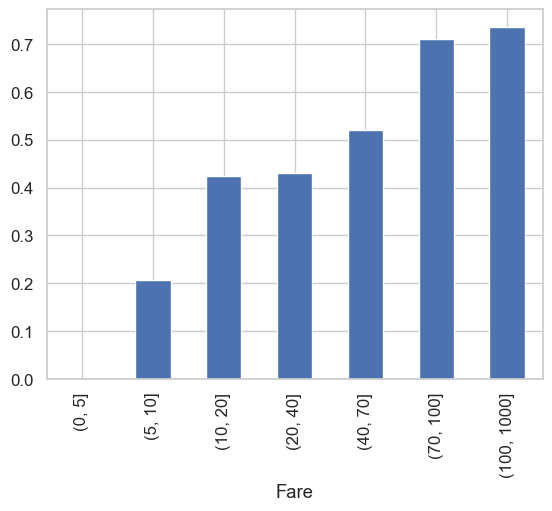

In [166]:
train_df['Survived'].groupby(pd.cut(train_df.Fare, [0,5,10,20,40,70,100,1000]),observed = False).mean().plot(kind='bar')

### Persons paying more than $70 have higher survival rate

In [186]:
print("SibSp description:")
print(train_df["SibSp"].describe())
print("\nParch description:")
print(train_df["Parch"].describe())

print("\nSibSp value counts:")
print(train_df["SibSp"].value_counts().sort_index())

print("\nParch value counts:")
print(train_df["Parch"].value_counts().sort_index())

train_df["FamilySize"] = train_df["SibSp"] + train_df["Parch"] + 1
print("\nFamilySize description:")
print(train_df["FamilySize"].describe())

SibSp description:
count    891.000000
mean       0.523008
std        1.102743
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        8.000000
Name: SibSp, dtype: float64

Parch description:
count    891.000000
mean       0.381594
std        0.806057
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        6.000000
Name: Parch, dtype: float64

SibSp value counts:
SibSp
0    608
1    209
2     28
3     16
4     18
5      5
8      7
Name: count, dtype: int64

Parch value counts:
Parch
0    678
1    118
2     80
3      5
4      4
5      5
6      1
Name: count, dtype: int64

FamilySize description:
count    891.000000
mean       1.904602
std        1.613459
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max       11.000000
Name: FamilySize, dtype: float64


## Distribution of SibSp (Siblings/Spouses)

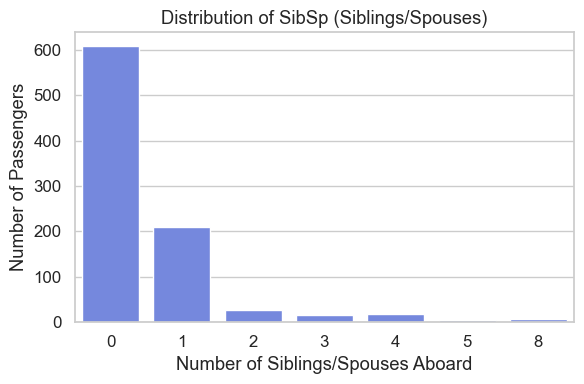

In [189]:
plt.figure(figsize=(6, 4))
sns.countplot(data=train_df, x="SibSp", color="#647DEE")
plt.title("Distribution of SibSp (Siblings/Spouses)")
plt.xlabel("Number of Siblings/Spouses Aboard")
plt.ylabel("Number of Passengers")
plt.tight_layout()
plt.show()


### The majority of the passengers travelled alone

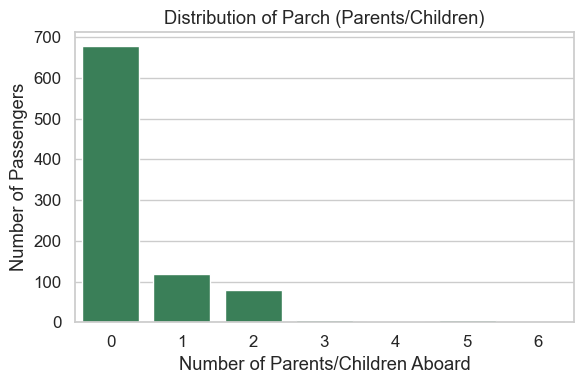

In [190]:
plt.figure(figsize=(6, 4))
sns.countplot(data=train_df, x="Parch", color="seagreen")
plt.title("Distribution of Parch (Parents/Children)")
plt.xlabel("Number of Parents/Children Aboard")
plt.ylabel("Number of Passengers")
plt.tight_layout()
plt.show()


### A good number travelled with one sibling or spouse

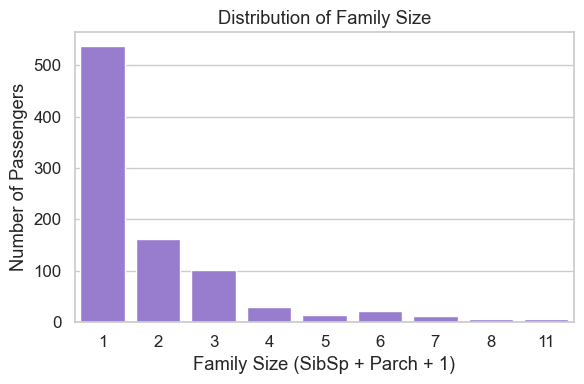

In [192]:
plt.figure(figsize=(6, 4))
sns.countplot(data=train_df, x="FamilySize", color="mediumpurple")
plt.title("Distribution of Family Size")
plt.xlabel("Family Size (SibSp + Parch + 1)")
plt.ylabel("Number of Passengers")
plt.tight_layout()
plt.show()

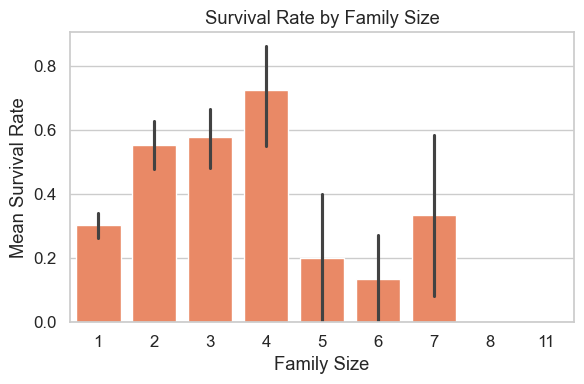

In [193]:
plt.figure(figsize=(6, 4))
sns.barplot(
    data=train_df,
    x="FamilySize",
    y="Survived",
    estimator="mean",
    color="coral"
)
plt.title("Survival Rate by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Mean Survival Rate")
plt.tight_layout()
plt.show()


## 1. Passengers with small families (2–4 members) had the highest survival rates, especially family size 4, which is almost 70%.
## 2. Passengers who were alone or had larger families (5–7 members) had lower survival rates, suggesting both isolation and very large groups were disadvantaged compared to medium‑sized families.

In [22]:
# Fare by cabin availability (has cabin vs no cabin)
train_df["HasCabin"] = train_df["Cabin"].notna().astype(int)


          count       mean        std     min       25%    50%        75%  \
Embarked                                                                    
C         168.0  59.954144  83.912994  4.0125  13.69795  29.70  78.500025   
Q          77.0  13.276030  14.188047  6.7500   7.75000   7.75  15.500000   
S         646.0  27.243651  35.952905  0.0000   8.05000  13.00  27.900000   

               max  
Embarked            
C         512.3292  
Q          90.0000  
S         263.0000  
          count       mean        std  min        25%       50%       75%  \
HasCabin                                                                    
0         687.0  19.157325  28.663343  0.0   7.877100  10.50000  23.00000   
1         204.0  76.141504  74.391749  0.0  29.453125  55.22085  89.32815   

               max  
HasCabin            
0         512.3292  
1         512.3292  
Embarked  HasCabin
C         0            30.983335
          1           101.520957
Q         0            11.26238

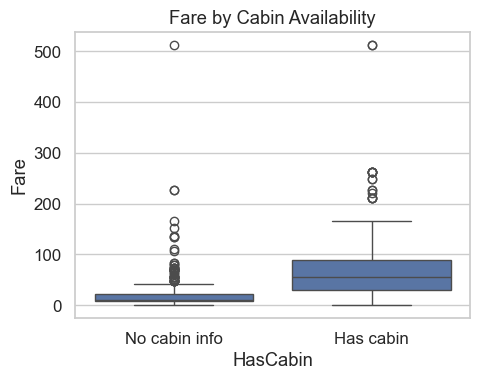

In [23]:
plt.figure(figsize=(5,4))
sns.boxplot(data=train_df, x="HasCabin", y="Fare")
plt.xticks([0,1], ["No cabin info", "Has cabin"])
plt.title("Fare by Cabin Availability")
plt.tight_layout()
plt.show()


### 1. Passengers with cabin information paid more than those without cabin information.
### 2. The group having no cabin information has a lower median, so most of them bought cheaper tickets, while a few have very expensive outlier fares.

In [26]:
train_df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,AgeGroup,HasCabin,TicketPrefix
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Adult,0,A521171
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Adult,1,PC17599
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Adult,0,STONO23101282
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Adult,1,113803
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Adult,0,373450


In [32]:
train_df["TicketPrefix"] = (
    train_df["Ticket"]
    .str.replace(r"\\d", "", regex=True)  
    .str.replace(r"[./ ]+", "", regex=True)  
    .str.upper()
)
train_df["TicketPrefix"].replace("", "NUMERIC", inplace=True)

C:\Users\habiba\AppData\Local\Temp\ipykernel_31108\328538460.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df["TicketPrefix"].replace("", "NUMERIC", inplace=True)


C:\Users\habiba\AppData\Local\Temp\ipykernel_31108\1480705411.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


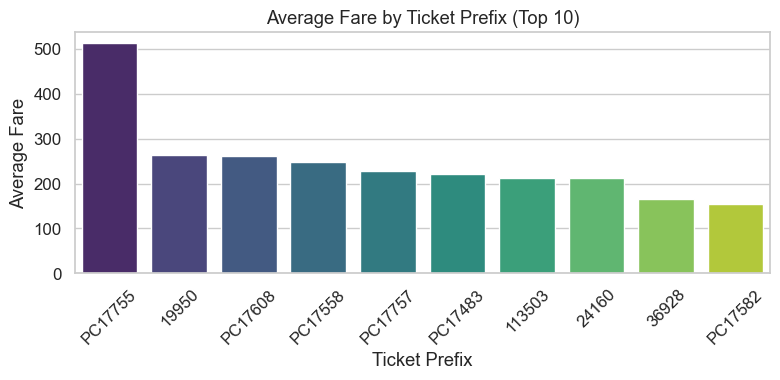

In [33]:
# top 10 prefixes
mean_fare_by_prefix = (
    train_df.groupby("TicketPrefix")["Fare"]
    .mean()
    .sort_values(ascending=False)
    .head(10)        
    .reset_index()
)

plt.figure(figsize=(8, 4))
sns.barplot(
    data=mean_fare_by_prefix,
    x="TicketPrefix",
    y="Fare",
    palette="viridis"
)
plt.title("Average Fare by Ticket Prefix (Top 10)")
plt.xlabel("Ticket Prefix")
plt.ylabel("Average Fare")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

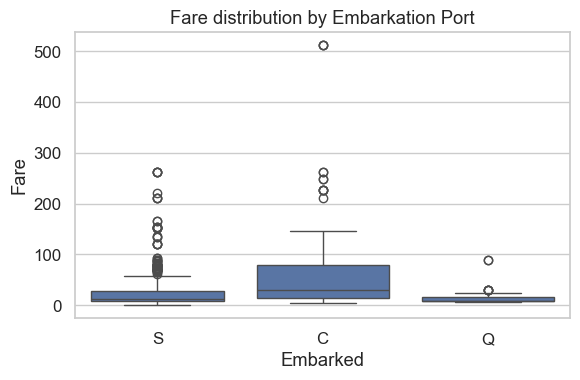

In [21]:
plt.figure(figsize=(6,4))
sns.boxplot(data=train_df, x="Embarked", y="Fare")
plt.title("Fare distribution by Embarkation Port")
plt.tight_layout()
plt.show()

### People boarding at Cherbourg paid more, including some extremely expensive tickets.

### People boarding at Southampton and Queenstown paid lower fares, and only a few paid very high prices.

## Finding duplicated rows

In [66]:
duplicates = train_df[train_df.duplicated()]

In [67]:
duplicates

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


### There is no duplication

In [13]:
titles = train_df["Name"].str.extract(r",\s*([^\.]+)\.")[0].tolist()

In [20]:
titles
title_counts = pd.Series(titles).value_counts()
title_counts

Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Col               2
Mlle              2
Major             2
Ms                1
Mme               1
Don               1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

In [22]:
train_df["Title"] = train_df["Name"].str.extract(r",\s*([^\.]+)\.")[0]

In [23]:
common_titles = ["Mr", "Miss", "Mrs", "Master"]
train_df["TitleGroup"] = train_df["Title"].where(
    train_df["Title"].isin(common_titles),
    other="Rare"
)

In [25]:
train_df["TitleGroup"].value_counts()

TitleGroup
Mr        517
Miss      182
Mrs       125
Master     40
Rare       27
Name: count, dtype: int64

In [36]:
percentage_surv_by_title = (
    train_df.groupby("TitleGroup")["Survived"]
        .value_counts(normalize=True)
        .mul(100)
        .rename("percent")
        .reset_index()
)

In [37]:
percentage_surv_by_Title

,TitleGroup,Survived,percent
0,Master,1,57.500000
1,Master,0,42.500000
2,Miss,1,69.780220
3,Miss,0,30.219780
4,Mr,0,84.332689
5,Mr,1,15.667311
6,Mrs,1,79.200000
7,Mrs,0,20.800000
8,Rare,0,55.555556
9,Rare,1,44.444444


In [39]:
survived_pct = percentage_surv_by_title.query("Survived == 1")
survived_pct

,TitleGroup,Survived,percent
0,Master,1,57.500000
2,Miss,1,69.780220
5,Mr,1,15.667311
6,Mrs,1,79.200000
9,Rare,1,44.444444


C:\Users\habiba\AppData\Local\Temp\ipykernel_30168\2714866277.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


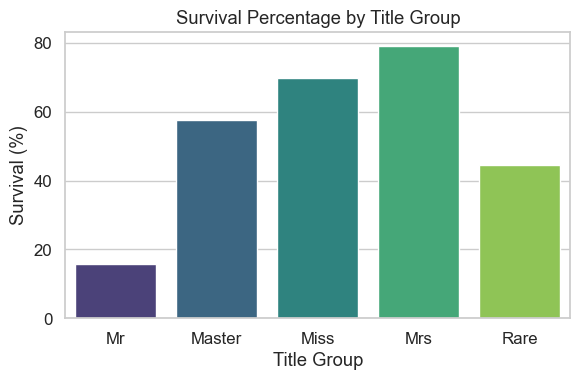

In [40]:
plt.figure(figsize=(6, 4))
sns.barplot(
    data=survived_pct,
    x="TitleGroup",
    y="percent",
    order=["Mr", "Master", "Miss", "Mrs", "Rare"],
    palette="viridis"
)
plt.title("Survival Percentage by Title Group")
plt.xlabel("Title Group")
plt.ylabel("Survival (%)")
plt.tight_layout()
plt.show()

In [41]:
train_df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,TitleGroup
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr,Mr


### Women and children (Miss, Mrs, Master) had much higher survival rates than adult men (Mr), and even people with rare, high‑status titles had better than ordinary men.

In [42]:
train_df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'Title', 'TitleGroup'],
      dtype='object')

In [43]:
train_df["Deck"] = (
    train_df["Cabin"]
        .fillna("Unknown")        # handle missing cabins
        .str.split()              # split 'C23 C25 C27' -> ['C23','C25','C27']
        .str[0]                   # keep first cabin
        .str[0]                   # keep first character -> deck letter
)

In [45]:
train_df[["Cabin", "Deck"]].head()

,Cabin,Deck
0,NaN,U
1,C85,C
2,NaN,U
3,C123,C
4,NaN,U


In [46]:
deck_survival = (
    train_df.groupby("Deck")["Survived"]
            .mean()
            .sort_values(ascending=False)
)
print(deck_survival)

Deck
D    0.757576
E    0.750000
B    0.744681
F    0.615385
C    0.593220
G    0.500000
A    0.466667
U    0.299854
T    0.000000
Name: Survived, dtype: float64


C:\Users\habiba\AppData\Local\Temp\ipykernel_30168\2004424439.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


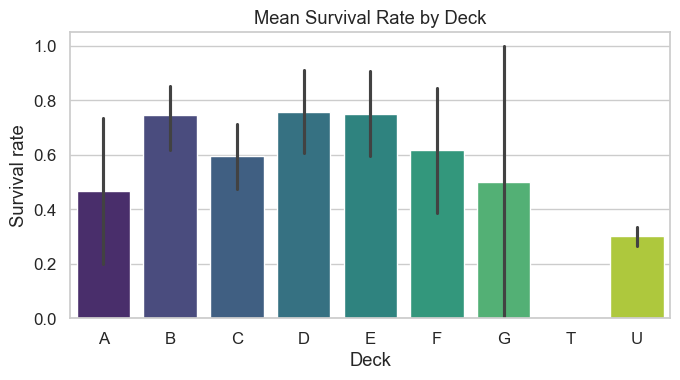

In [47]:
plt.figure(figsize=(7, 4))
sns.barplot(
    data=train_df,
    x="Deck",
    y="Survived",
    estimator="mean",
    order=sorted(train_df["Deck"].unique()),
    palette="viridis"
)
plt.title("Mean Survival Rate by Deck")
plt.ylabel("Survival rate")
plt.tight_layout()
plt.show()

In [48]:
pd.crosstab(train_df["Deck"], train_df["Pclass"], normalize="index")

Pclass,1,2,3
Deck,,,
A,1.000000,0.000000,0.000000
B,1.000000,0.000000,0.000000
C,1.000000,0.000000,0.000000
D,0.878788,0.121212,0.000000
E,0.781250,0.125000,0.093750
F,0.000000,0.615385,0.384615
G,0.000000,0.000000,1.000000
T,1.000000,0.000000,0.000000
U,0.058224,0.244541,0.697234


## Deck information:
* Deck A, B, C -> 100% 1st‑class cabins
* Deck D -> Mostly luxury 1st‑class, with some 2nd‑class.
* Deck E -> Mixed but still dominated by 1st‑class.
* Deck F -> No 1st‑class, mostly 2nd and 3rd‑class.
* Deck G -> Only 3rd‑class here.
* Deck U(Unknown) -> When the cabin is missing, the passenger is usually 3rd‑class.    

# Info gained from Wikipedia
## link:https://www.encyclopedia-titanica.org/titanic-deckplans/

In [51]:
train_df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,TitleGroup,Deck
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr,Mr,U
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,Mrs,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss,Miss,U
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs,Mrs,C
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr,Mr,U


## Outlier Detection For Important Numerical Features

### Age 

<Axes: xlabel='Age'>

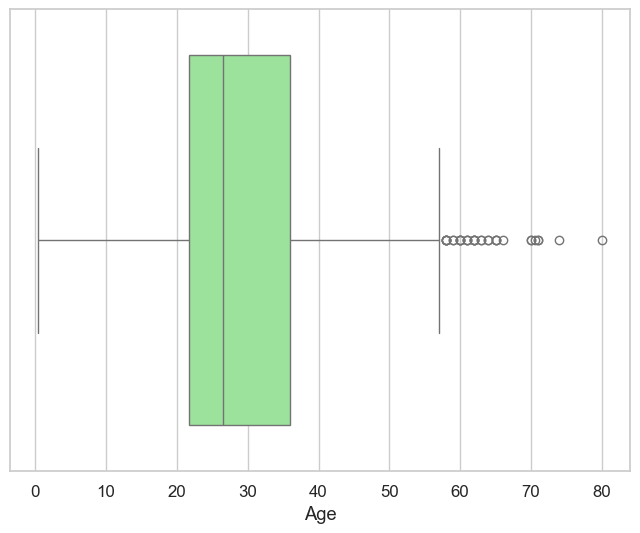

In [53]:
plt.figure(figsize=(8, 6)) 
sns.boxplot(x=train_df.Age, color='lightgreen')

### Mean, Standard Deviation, Z-score, Outliers using Z-score

In [ ]:
mean_age = np.mean(train_df.Age)
std_dev_age = np.std(train_df.Age)
Z_scores_age = (train_df.Age - mean_age) / std_dev_age
outliers_age = train_df.Age[np.abs(Z_scores_age) > 3]
print("Outliers in 'Age' using Z-score: \n", outliers_age)
Q1 = train_df.Age.quantile(0.25)
Q3 = train_df.Age.quantile(0.75) 
IQR = Q3 - Q1
outliers = train_df.Age[
    (train_df.Age < (Q1 - 1.5 * IQR)) |
    (train_df.Age > (Q3 + 1.5 * IQR))
]
print("Outliers in 'Age' using Inter-Quartile-Range: \n", outliers)

In [58]:
print(Q1)
print(Q3)

21.75
36.0


### Replacing outliers for Age(Capping)

In [60]:
upper_bound = Q3 + 1.5 * IQR
train_df.Age = np.where(train_df.Age > upper_bound, upper_bound, train_df.Age)

### Fare

<Axes: xlabel='Fare'>

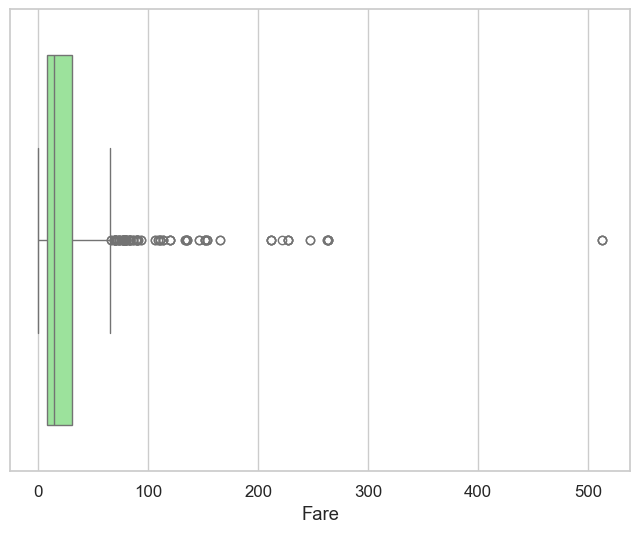

In [54]:
plt.figure(figsize=(8, 6)) 
sns.boxplot(x=train_df.Fare, color='lightgreen')

### Mean, Standard Deviation, Z-score, Outliers using Z-score

In [61]:
mean_fare = np.mean(train_df.Fare)
std_dev_fare = np.std(train_df.Fare)
Z_scores_fare = (train_df.Fare - mean_fare) / std_dev_fare
outliers_fare = train_df.Fare[np.abs(Z_scores_fare) > 3]
print("Outliers in 'Fare' using Z-score: \n", outliers_fare)
Q1 = train_df.Fare.quantile(0.25)
Q3 = train_df.Fare.quantile(0.75) 
IQR = Q3 - Q1
outliers = train_df.Fare[
    (train_df.Fare < (Q1 - 1.5 * IQR)) |
    (train_df.Fare > (Q3 + 1.5 * IQR))
]
print("Outliers in 'Fare' using Inter-Quartile-Range: \n", outliers)

Outliers in 'Fare' using Z-score: 
 27     263.0000
88     263.0000
118    247.5208
258    512.3292
299    247.5208
311    262.3750
341    263.0000
377    211.5000
380    227.5250
438    263.0000
527    221.7792
557    227.5250
679    512.3292
689    211.3375
700    227.5250
716    227.5250
730    211.3375
737    512.3292
742    262.3750
779    211.3375
Name: Fare, dtype: float64
Outliers in 'Fare' using Inter-Quartile-Range: 
 1       71.2833
27     263.0000
31     146.5208
34      82.1708
52      76.7292
         ...   
846     69.5500
849     89.1042
856    164.8667
863     69.5500
879     83.1583
Name: Fare, Length: 116, dtype: float64


### Replacing outliers for Fare(Capping)

In [62]:
upper_bound = Q3 + 1.5 * IQR
train_df.Fare = np.where(train_df.Fare > upper_bound, upper_bound, train_df.Fare)

In [70]:
train_df.Age.mean()

np.float64(29.69911764705882)

In [72]:
train_df.Age.mode()[0]

np.float64(24.0)

In [74]:
train_df.Age.median()

28.0

In [4]:
mean_ages = train_df.groupby(by=["Pclass","Sex"]).Age.mean()
mean_ages

Pclass  Sex   
1       female    34.611765
        male      41.281386
2       female    28.722973
        male      30.740707
3       female    21.750000
        male      26.507589
Name: Age, dtype: float64

### Replaced the missing value with the mean age of passengers in the same passenger class and sex group.

In [5]:
def fill_missing_age(row):
    if pd.isna(row["Age"]):
        return mean_ages.loc[(row["Pclass"], row["Sex"])]
    else:
        return row["Age"]

In [6]:
train_df.Age = train_df.apply(fill_missing_age , axis=1)

In [10]:
train_df.Age.isnull().sum()

np.int64(0)

## Missing Embarked

In [11]:
train_df.Embarked.mode()[0]

'S'

In [12]:
missing = train_df[train_df.Embarked.isnull()]
missing

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


 ### Both were travelling in the same cabin and with the same ticket number, and most of the passengers were travelling from Southampton.So we imputed missing embarked values with Southampton.

In [7]:
train_df.Embarked.fillna("S",inplace  = True)

C:\Users\habiba\AppData\Local\Temp\ipykernel_30168\2374937099.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df.Embarked.fillna("S",inplace  = True)


In [14]:
train_df.Ticket.dtype

dtype('O')

In [8]:
train_df_tickets = train_df[(train_df.Ticket == "113572") & (train_df.Cabin == "B28")]
train_df_tickets

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,S
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,S


In [9]:
embarked_counts = train_df.Embarked.value_counts().sort_index()
embarked_counts

Embarked
C    168
Q     77
S    646
Name: count, dtype: int64

In [97]:
embarked_counts.index

Index(['C', 'Q', 'S'], dtype='object', name='Embarked')

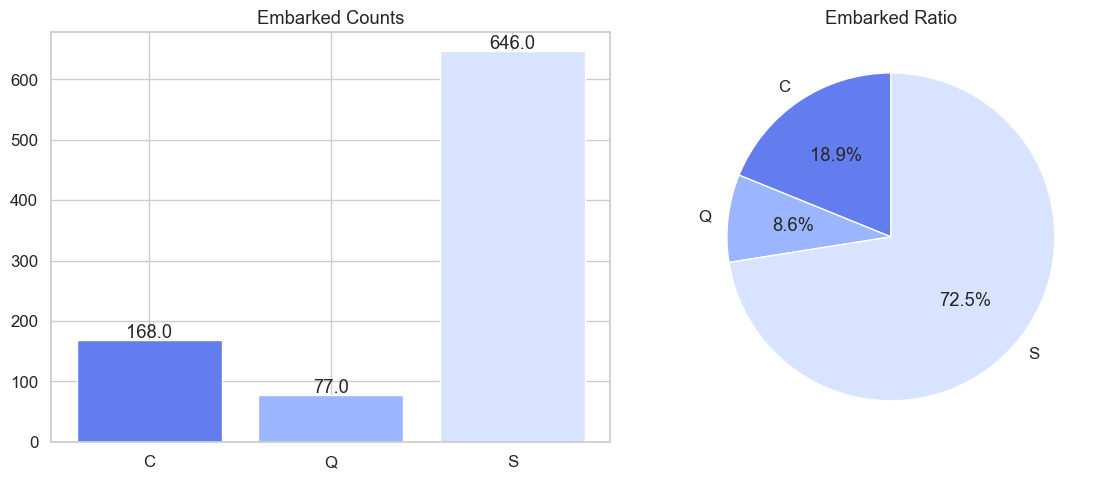

In [10]:
ports = list(embarked_counts.index)
counts = list(embarked_counts.values)
percents = [c / sum(counts) * 100 for c in counts]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(ports, counts, color=['#647DEE', '#9BB5FF', '#D7E3FF'])
for i, v in enumerate(counts):
    axes[0].text(i, v + 5, f'{v:.1f}', ha='center')
axes[0].set_title('Embarked Counts')
axes[1].pie(
    counts,
    labels=ports,
    autopct='%1.1f%%',
    colors=['#647DEE', '#9BB5FF', '#D7E3FF'],
    startangle=90
)
axes[1].set_title('Embarked Ratio')

plt.tight_layout()
plt.show()

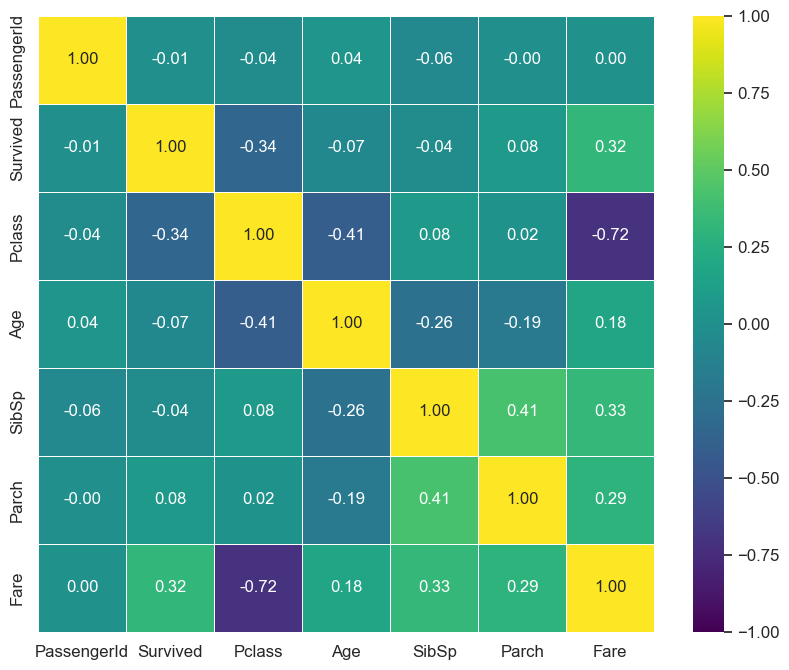

In [83]:
correlation_matrix = train_df.corr(numeric_only = True)
plt.figure(figsize = (10,8))
plt.rcParams.update({'font.size': 12})
sns.heatmap(correlation_matrix, cmap = 'viridis', vmin = -1, vmax = 1, center = 0, annot=True, fmt=".2f", square=True, linewidths=.5)
plt.show()


### The heatmap shows that survival is moderately related to **Pclass** (higher class -> more survival) and **Fare** (higher fare -> more survival), while **Age** has only a very weak linear relationship with survival.

In [87]:
import_feature = train_df[['Survived','Sex','Age','Fare']]

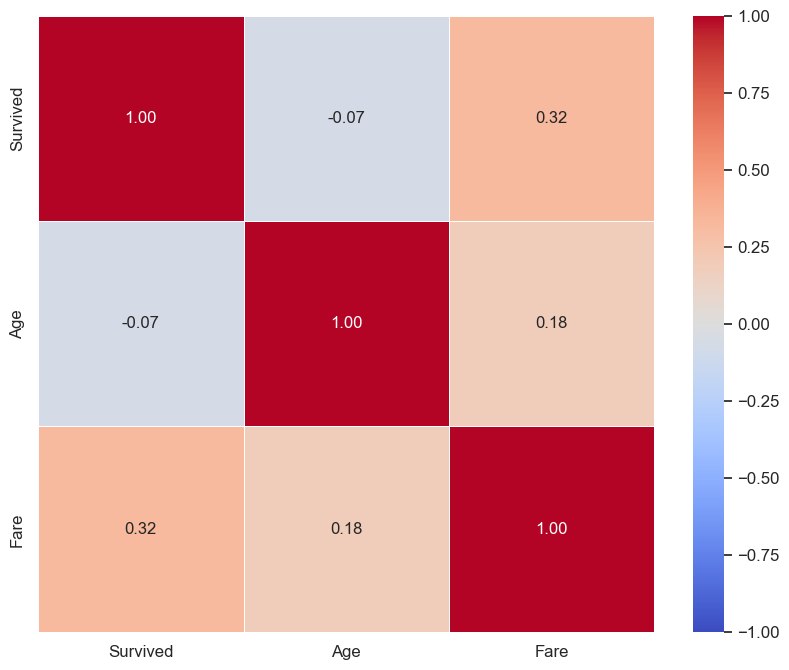

In [94]:
correlation_matrix = import_feature.corr(numeric_only = True)
plt.figure(figsize = (10,8))
plt.rcParams.update({'font.size': 12})
sns.heatmap(correlation_matrix, cmap = 'coolwarm', vmin = -1, vmax = 1, center = 0, annot=True, fmt=".2f", square=True, linewidths=.5)
plt.show()

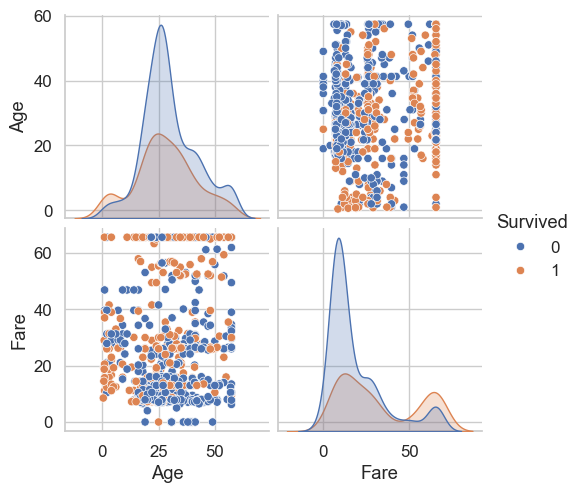

In [91]:
sns.pairplot(import_feature, hue='Survived')

<Axes: xlabel='Age', ylabel='Fare'>

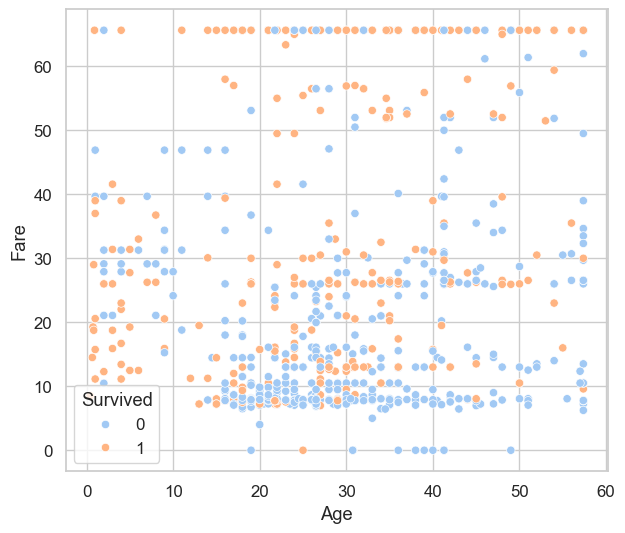

In [95]:
plt.figure(figsize=(7, 6))
sns.scatterplot(x='Age', y='Fare', data=import_feature, hue='Survived', palette='pastel')

## Create a new column for the passenger's age group ("Child," "Adult," "Senior") based on the 'Age' column.


In [11]:
def classify_age(age):
    if age < 18:
        return "Child"
    elif age < 60:
        return "Adult"
    else:
        return "Senior"

In [11]:
train_df['AgeGroup'] = train_df.Age.apply(classify_age)

In [12]:
train_df.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C


## There is no date related column

# Hypothesis Testing

### Previously, we have seen that the Pclass affects the survival rate; the higher the class, the higher the survival rate is. But, we are not sure whether this has been because of any random, independent, unbiased, or even representative reason. Thats why we will use hypothesis testing here called Z-testing.
* Null Hypothesis: The socio-economic class of the people didn’t affect the survival rate.
* Alternative Hypothesis: The socio-economic class of the people affected their survival rate.

### For the z-test, the two populations have to be normally distributed.

### Taking 100 sample population of each class 

In [65]:
first_Class_Sample = np.array([train_df[train_df.Pclass == 1]['Survived'].sample(20).mean() for i in range(100)])
second_Class_Sample = np.array([train_df[train_df.Pclass == 2]['Survived'].sample(20).mean() for i in range(100)])
third_Class_Sample = np.array([train_df[train_df.Pclass == 3]['Survived'].sample(20).mean() for i in range(100)])

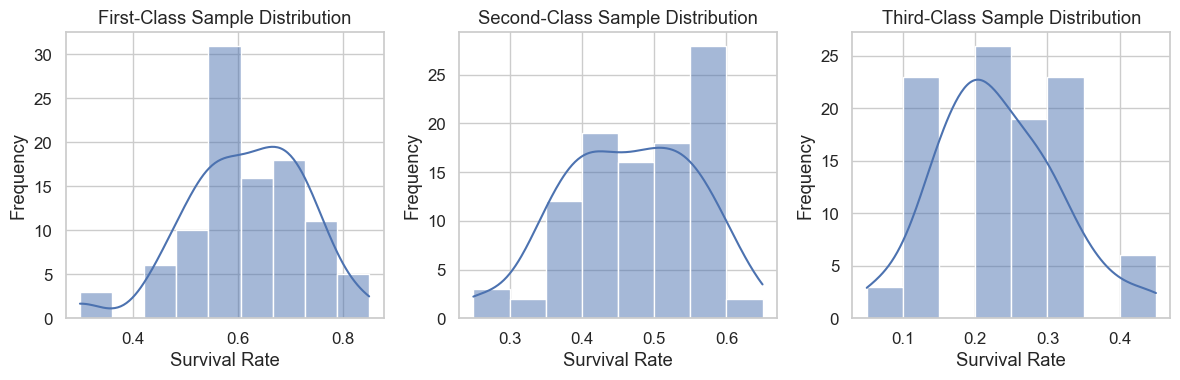

In [70]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

sns.histplot(first_Class_Sample, kde=True, ax=axes[0])
axes[0].set_title("First-Class Sample Distribution")
axes[0].set_xlabel("Survival Rate")
axes[0].set_ylabel("Frequency")

sns.histplot(second_Class_Sample, kde=True, ax=axes[1])
axes[1].set_title("Second-Class Sample Distribution")
axes[1].set_xlabel("Survival Rate")
axes[1].set_ylabel("Frequency")

sns.histplot(third_Class_Sample, kde=True, ax=axes[2])
axes[2].set_title("Third-Class Sample Distribution")
axes[2].set_xlabel("Survival Rate")
axes[2].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

### Now we will calculate p‑values and set the significance level for a Z-test
* Significance level (like 0.05) is the cutoff we choose before testing:
* If p‑value < 0.05, we reject the null;
* If p‑value ≥ 0.05, we keep it, accepting up to a 5% chance that a significant effect is actually just randomness.

In [75]:
effect = np.mean(first_Class_Sample) - np.mean(third_Class_Sample)
# sample standard deviations of the sampling distributions
sigma_first = np.std(first_Class_Sample, ddof=1)
sigma_third = np.std(third_Class_Sample, ddof=1)
# standard error of the difference in means
sigma_difference = np.sqrt((sigma_first**2)/len(first_Class_Sample) +(sigma_third**2)/len(third_Class_Sample))
z_score = effect / sigma_difference
print(f"{z_score:.2f}")

27.36


In [76]:
from scipy import stats as st

In [77]:
st.norm.sf(abs(z_score))*2

np.float64(7.45880611337571e-165)

### As p-value << 0.05, we will reject the null hypothesis ,so the Pclass has actually have significant effect on survival rate

### From the age histogram, we have already seen that survival may vary with age (children and some older passengers seem to have higher survival), so we now use a t‑test to formally check whether the average Age differs between survivors and non‑survivors.
* Null Hypothesis: Survival does not depend on Age in terms of the mean.
* Alternative Hypothesis: The average/mean Age is different between survivors and non‑survivors.
* Welch t-test (doesn't assume equal variances)

In [81]:
age_surv = train_df.loc[train_df.Survived == 1, 'Age']
age_dead = train_df.loc[train_df.Survived == 0, 'Age']
t_stat, p_val = st.ttest_ind(age_surv, age_dead, equal_var=False)
print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_val:.5f}")

T-statistic: -1.897
P-value: 0.05829


### We do not have strong statistical evidence that survivors and non‑survivors differ in average Age. Although p is close to 0.05, there might be a weak trend.

### From previous work, we have noticed that survival depends heavily on 'Sex'.We will now test it using the Chi-square Test
* Null Hypothesis: Survival does not depend on 'Sex'.
* Alternative Hypothesis: Survival depends heavily on 'Sex'.

In [82]:
sex_surv = pd.crosstab(train_df.Sex, train_df.Survived)
chi2,p,dof,exp = st.chi2_contingency(sex_surv)
print("Sex vs Survived chi2:", chi2, "p-value:", p)

Sex vs Survived chi2: 260.71702016732104 p-value: 1.1973570627755645e-58


### As p-value << 0.001, we will reject the null hypothesis. So, survival depends strongly on 'Sex'.